In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [2]:
train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
train_tuple = []
test_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            train_tuple.append((image_x,image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [3]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

900
(128, 128, 3)
(512, 512, 3)


In [6]:
def plot_images(index):
    img1 = train_tuple[index][0]
    img2 = train_tuple[index][1]
    
    # Get dimensions
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Create figure big enough to hold both images
    fig = plt.figure(figsize=((w1 + w2) / 100, max(h1, h2) / 100))
    
    # Axes for first image
    ax1 = fig.add_axes([0, 0, w1 / (w1 + w2), 1])  # [left, bottom, width, height] in 0-1 range
    ax1.imshow(img1)
    ax1.axis('off')
    
    # Axes for second image
    ax2 = fig.add_axes([w1 / (w1 + w2), 0, w2 / (w1 + w2), 1])
    ax2.imshow(img2)
    ax2.axis('off')
    
    plt.show()

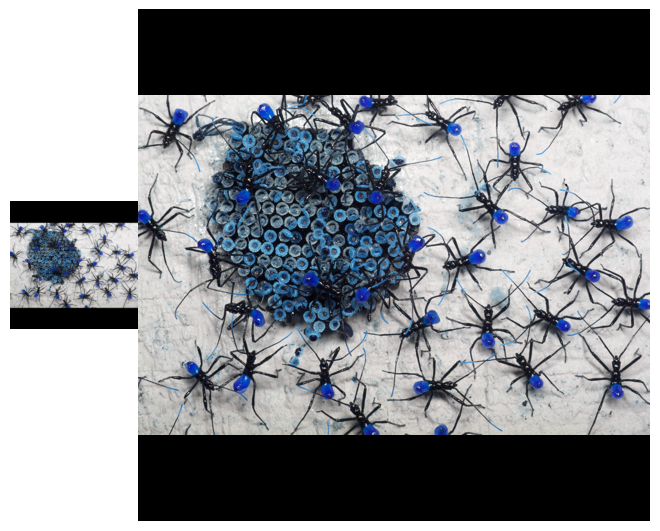

In [7]:
plot_images(500)

In [4]:
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from PIL import Image

def fourier_upscale(image, scale_factor=4):
    upscaled_channels = []

    for c in range(3):  # For R, G, B channels
        # Get single channel
        channel = image[:, :, c]

        # Forward FFT
        F = fft2(channel)
        F_shifted = fftshift(F)

        # Zero-padding in frequency domain
        h, w = channel.shape
        new_h, new_w = h * scale_factor, w * scale_factor
        F_padded = np.zeros((new_h, new_w), dtype=complex)

        # Place the original spectrum in the center of the padded one
        h_center, w_center = new_h // 2, new_w // 2
        h_half, w_half = h // 2, w // 2
        F_padded[h_center - h_half:h_center + h_half, w_center - w_half:w_center + w_half] = F_shifted

        # Inverse FFT
        F_unshifted = ifftshift(F_padded)
        upscaled = np.real(ifft2(F_unshifted))

        # ✅ Rescale intensities
        upscaled *= scale_factor ** 2  # Rescale to preserve brightness

        # Normalize to [0, 255]
        upscaled = np.clip(upscaled, 0, 255)
        upscaled_channels.append(upscaled.astype(np.uint8))

    # Stack the 3 upscaled channels
    upscaled_img = np.stack(upscaled_channels, axis=2)
    return upscaled_img

In [16]:
def loss_and_y_pred():
    l1_total = 0
    l2_total = 0
    psnr=0
    ssim=0
    
    for x_train, y_train in train_tuple:
        pred = fourier_upscale(x_train)

        pred = np.array(pred)
        y_train = np.array(y_train)

        l1_loss = np.mean(np.abs(pred - y_train))
        l2_loss = np.mean((pred - y_train) ** 2)

        psnr += peak_signal_noise_ratio(y_train, pred, data_range=255)
        ssim += structural_similarity(y_train, pred, channel_axis=-1, data_range=255)

        l1_total += l1_loss
        l2_total += l2_loss

    l1_avg = l1_total / len(train_tuple)
    l2_avg = l2_total / len(train_tuple)
    psnr_avg = psnr / len(train_tuple)
    ssim_avg = ssim / len(train_tuple)
    return l1_avg, l2_avg, psnr_avg, ssim_avg

In [17]:
l1_avg, l2_avg, psnr_avg, ssim_avg = loss_and_y_pred()

In [18]:
print("l1_loss: ",l1_avg)
print("l2_loss: ",l2_avg)
print("psnr_avg: ",psnr_avg)
print("ssim_avg: ",ssim_avg)

l1_loss:  84.32125264768246
l2_loss:  38.12288509227608
psnr_avg:  24.53583470433089
ssim_avg:  0.7626925488467645


In [25]:
def visualize(index):
    x_train = train_tuple[index][0]
    y_pred = fourier_upscale(x_train)
    y_train = train_tuple[index][1]
    
    # Get dimensions
    h1, w1 = x_train.shape[:2]
    h2, w2 = y_pred.shape[:2]
    h3, w3 = y_train.shape[:2]
    
    # Create figure big enough to hold both images
    fig = plt.figure(figsize=((w1 + w2 + w3) / 100, max(h1, h2, h3) / 100))
    
    # Axes for first image
    ax1 = fig.add_axes([0, 0, w1 / (w1 + w2 + w3), 1])  # [left, bottom, width, height] in 0-1 range
    ax1.imshow(x_train)
    ax1.axis('off')
    
    # Axes for second image
    ax2 = fig.add_axes([w1 / (w1 + w2 + w3), 0, w2 / (w1 + w2 + w3), 1])
    ax2.imshow(y_pred)
    ax2.axis('off')
    
    # # Axes for third image
    ax3 = fig.add_axes([(w2+w1) / (w1 + w2 + w3), 0, w3 / (w1 + w2 + w3), 1])
    ax3.imshow(y_train)
    ax3.axis('off')
    
    plt.show()

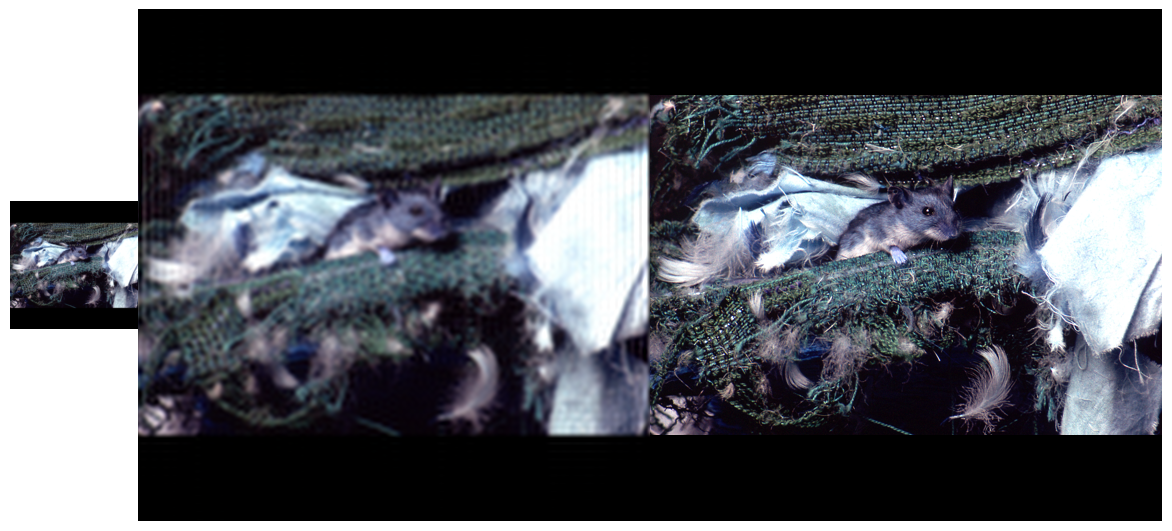

In [26]:
visualize(111)

In [27]:
index=201

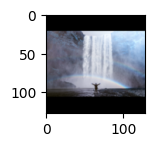

In [28]:
x_train = train_tuple[index][0]
h, w = x_train.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(x_train)
plt.show()

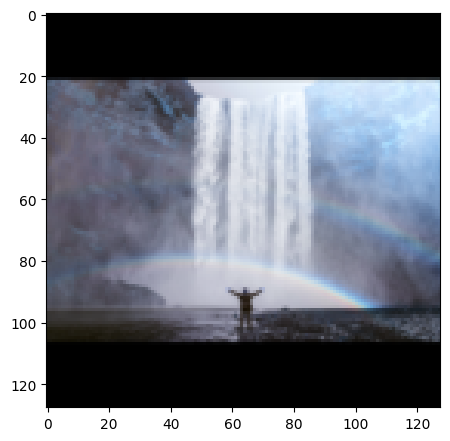

In [31]:
x_train = train_tuple[index][0]
h, w = x_train.shape[:2]
fig = plt.figure(figsize=(w*4 / 100, h*4 / 100))  # Scale by DPI or just by a factor
plt.imshow(x_train)
plt.show()

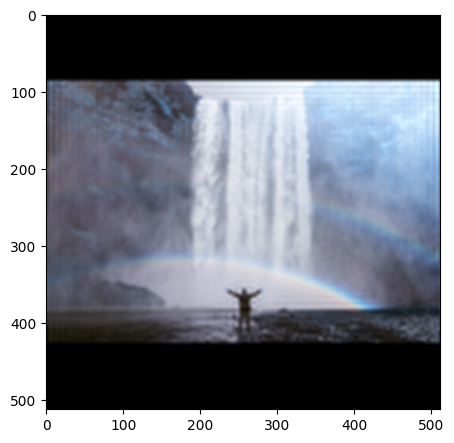

In [29]:
y_pred =  fourier_upscale(train_tuple[index][0])
h, w = y_pred.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(y_pred)
plt.show()

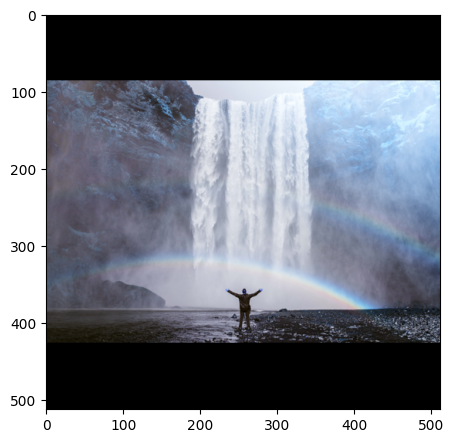

In [30]:
y_train = train_tuple[index][1]
h, w = y_train.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(y_train)
plt.show()

In [5]:
def vis_2(index):
    import matplotlib.pyplot as plt

    # Assuming x_train, y_pred, and y_train are the images you want to display
    x_train = train_tuple[index][0]
    y_pred = fourier_upscale(x_train)
    y_train = train_tuple[index][1]
    
    # Create a figure with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot the images
    axs[0].imshow(x_train, cmap='gray')
    axs[0].set_title('x_train')
    axs[0].axis('off')  # Turn off axis
    
    axs[1].imshow(y_pred, cmap='gray')
    axs[1].set_title('y_pred')
    axs[1].axis('off')  # Turn off axis
    
    axs[2].imshow(y_train, cmap='gray')
    axs[2].set_title('y_train')
    axs[2].axis('off')  # Turn off axis
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


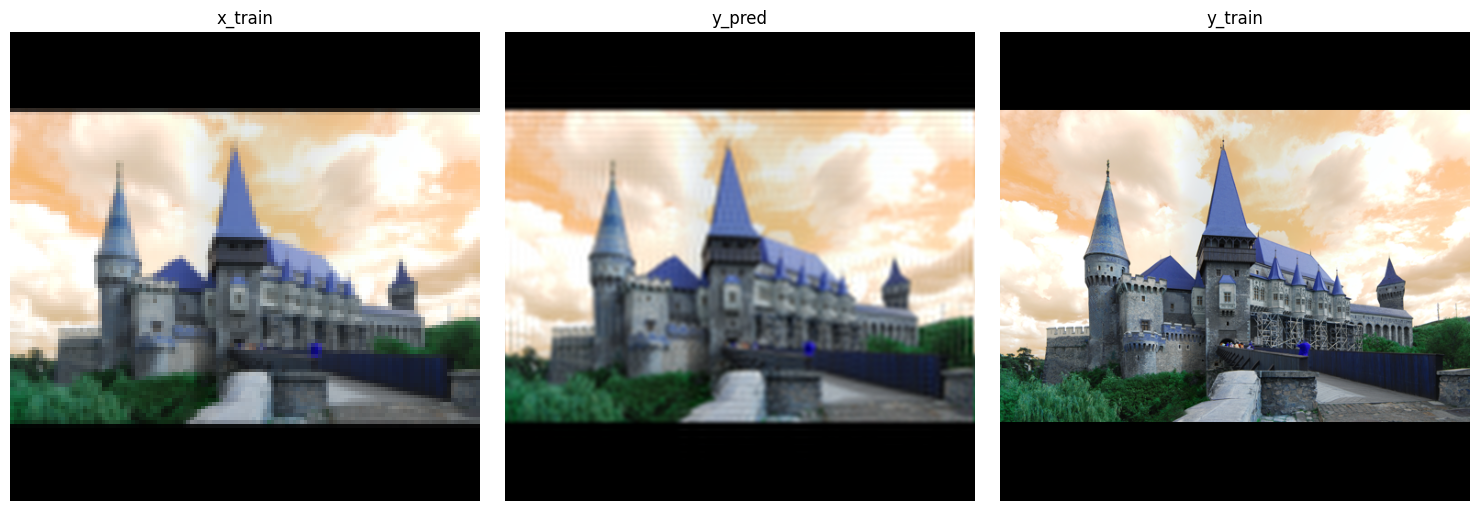

In [31]:
vis_2(700)

###### 